期貨開高，突破17000點：

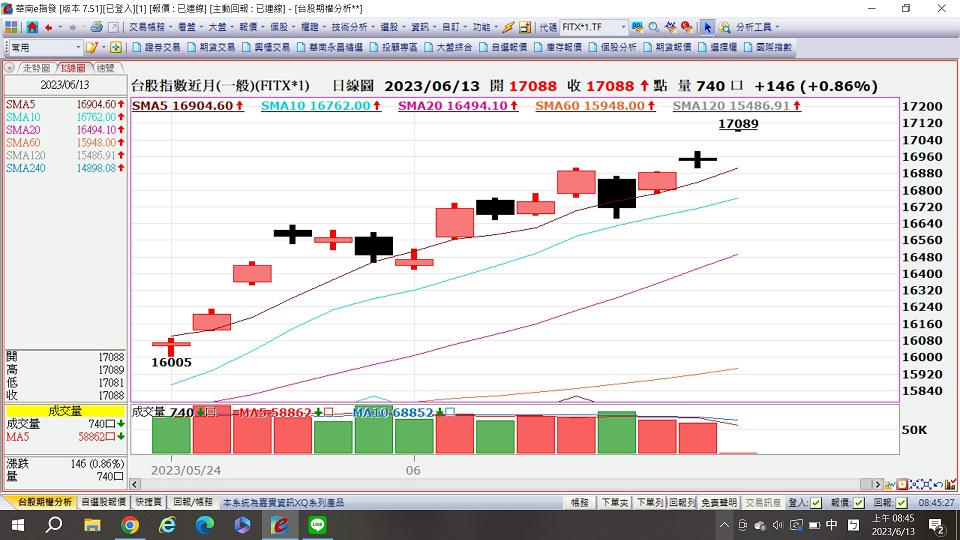

[加權指數開高上漲](https://tinyurl.com/34th7aza)，延續周末影音解盤，想用目標滿足法的同學，可以觀察17250-17400。  
想用支撐跌破法的同學，觀察單日從最高點拉回200點以上，或3日累計300點以上(也就是出現爆量長黑或長上影線)。  
當然也可以兩者同步觀察。  
另外，雖然指數創高，但扣除台積電的部分，漲點只剩下60多點，28大類股中，真正創高只有3類。  

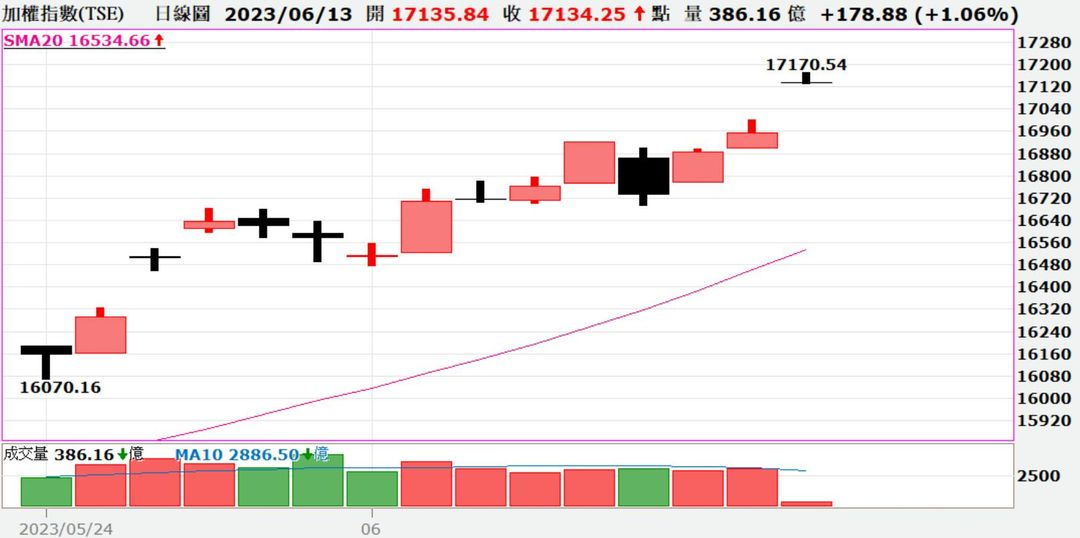

加權指數創高，上漲207點：

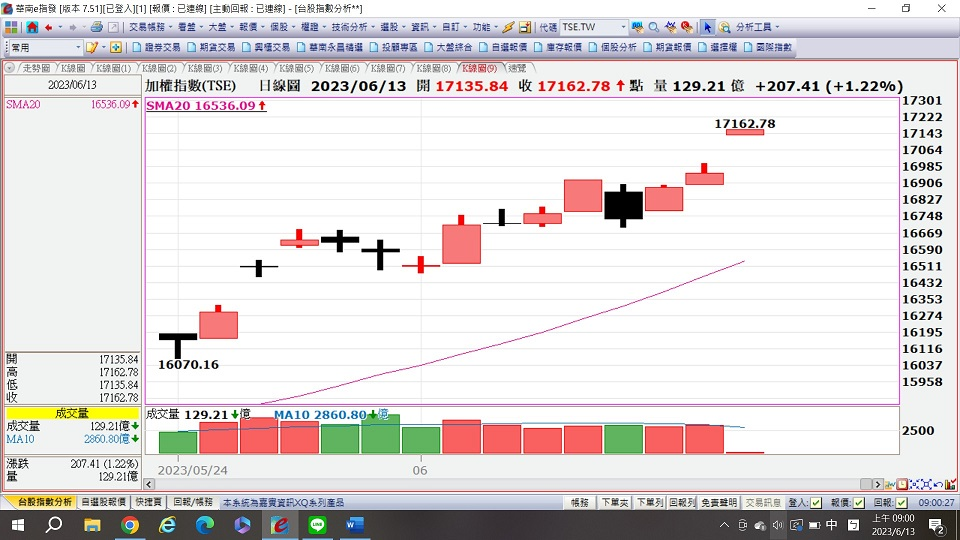

櫃買指數也是創高，不過漲幅相對小：

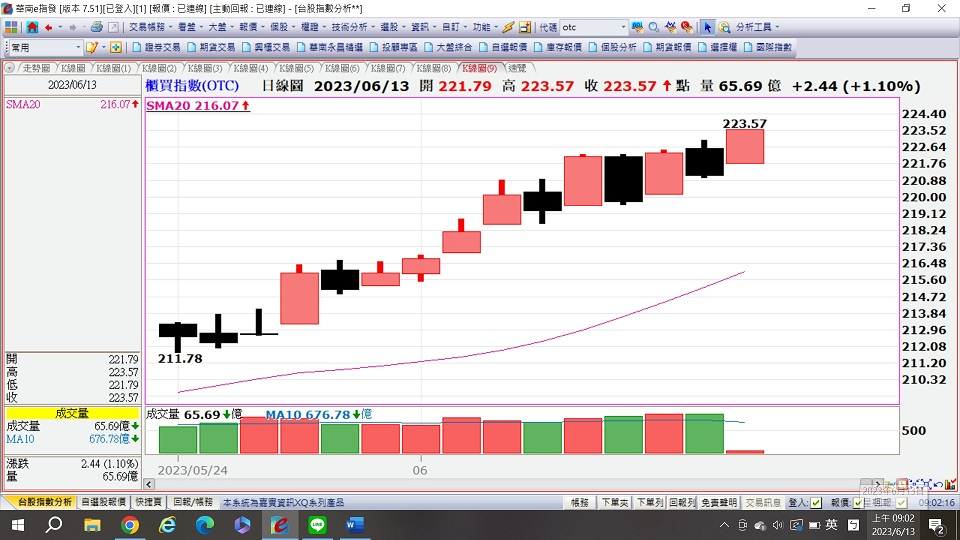

今天多方類股：

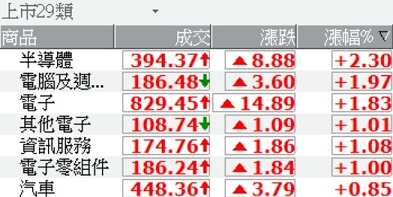  
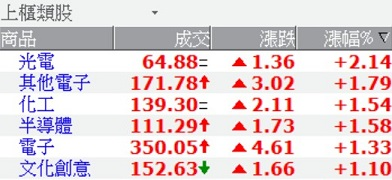  

創高類股：

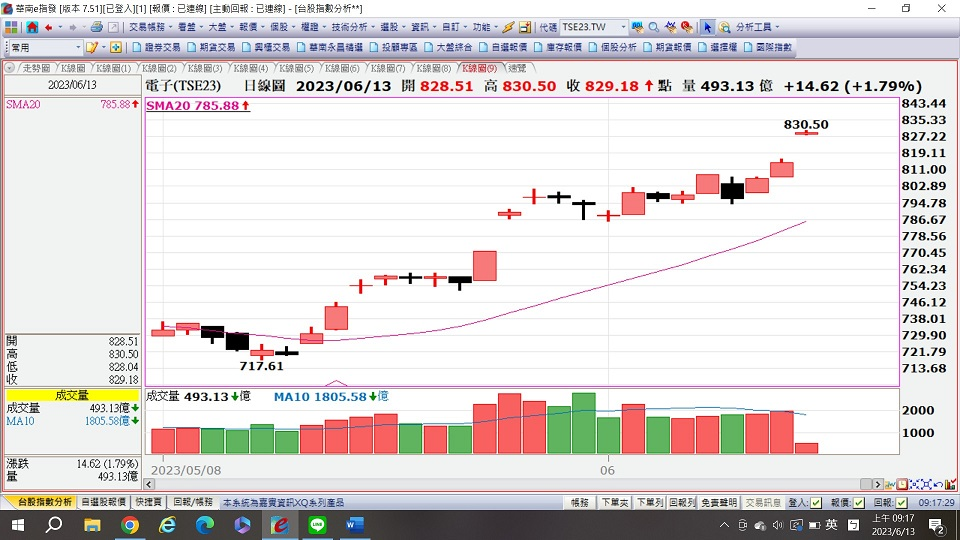  
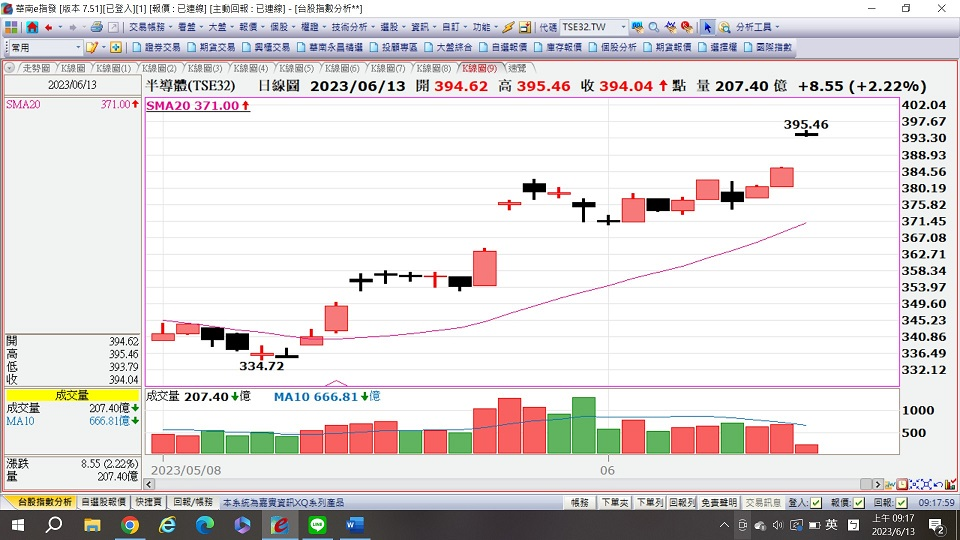  
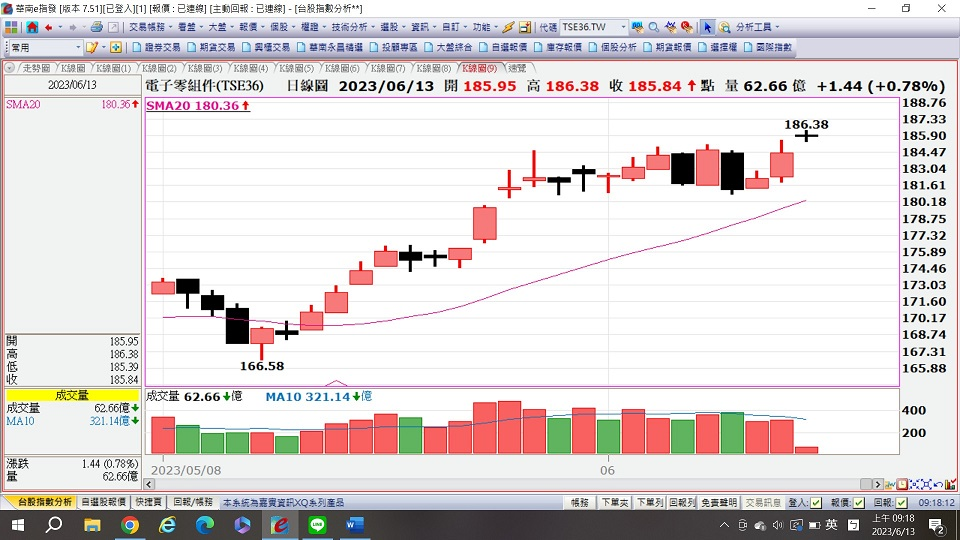  

只有三類；雖然指數創高，但扣除台積電的部分，漲點只剩下60多點。  

一檔穩健的強勢股，尤其是個股走勢，通常會出現階梯式上漲的現象，也就是漲勢停歇並沒有拉回，而是用橫盤的方式，然後越墊越高，橫盤時間越盤越短，直至最後在市場最樂觀的時候高檔噴出。  
這種現象其實在個股很常見，可以參考圓展的走勢，但是在指數中比較少見，我試著找這幾年指數的表現，比較少有這種走勢，比較接近的是2021年5月的航運指數，大家可以對照看看，上周已經有畫過圖，剛剛最新的走勢再補上，就一起來觀察，未來會不會複製這樣的走勢吧！  
至於為什麼個股常常出現，但指數比較少見，等真的修正之後再來聊。  

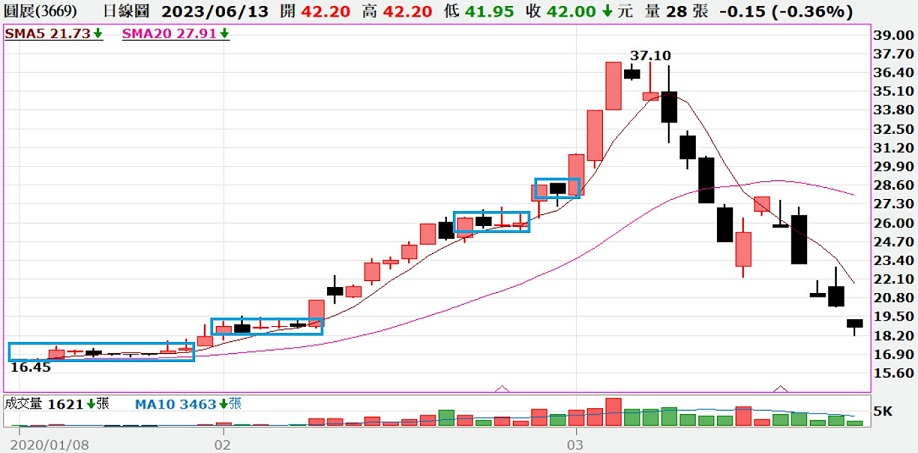  
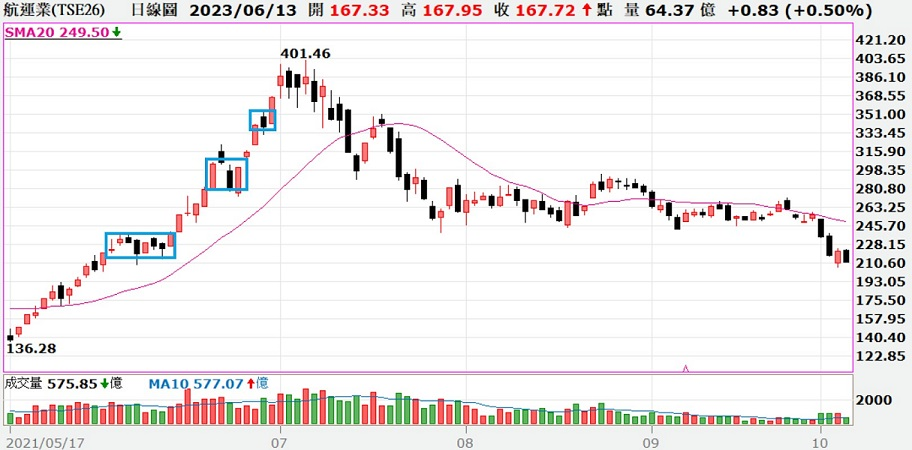  

[是還是要提醒各位](https://tinyurl.com/muzmf5vm)，現在就是位階高，市場過熱，但還是多頭，你不要急著去空指數商品(期貨、選擇權)，那會很危險，這幾個月看法都一樣，不管做多做空還是挑個股比較好，操作的SOP不要忘記：1.選股2買點3.目標價，符合要件才能出手。  
至於ETF那是長期商品，不論做多做空，都是用長期思維，真的是比氣長，要用分批去平衡成本，可以定期定額、定期不定額、不定期定額、不定期不定額(要用哪一種因人而異，會為資金比重和風險承受度而不同)，投資思維要用年以上為單位，降低波動的風險。  
然後會覺得選股很難是正常的，因為28大類股只有3類創高，意味著其他類股都是盤整，不然就是走弱中，也就是要挑中會漲的個股，只有10%甚至5%的機率。  

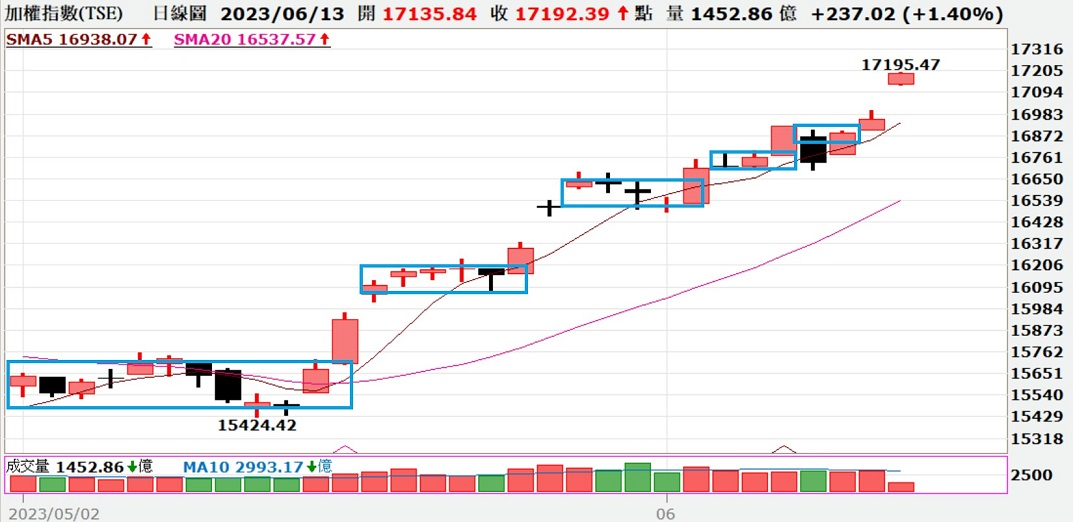

其實這一波，日本也有類似現象：

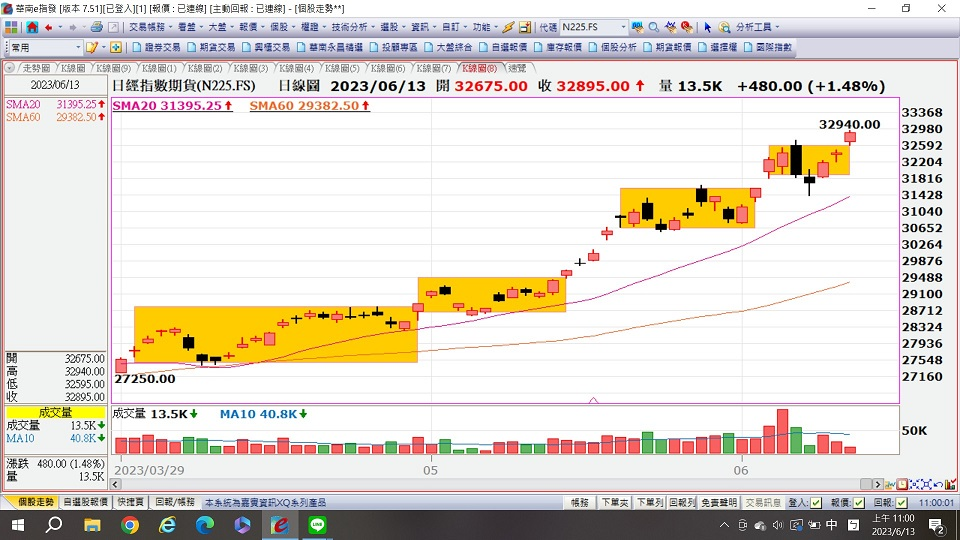

### 本日進度  
* 華航(2610)現持有3張(**預計持有10張**)，庫存現值68,250元(收盤價：22.75元，漲0.40元)。**停損價：21.65元，目標價：25.15元**。 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
from datetime import datetime
from scipy.signal import argrelextrema

In [2]:
##### 未實現損益 #####
stock_gains_losses = [['2610','華航',3000,65342,21.78,22.75,67949,2607,3.99]]
gains_losses_df = pd.DataFrame(stock_gains_losses,columns=['代碼', '股票名稱','即時庫存','付出成本','成本均價','現價','現值','損益試算','獲利率%'])
print('未實現損益：')
display(gains_losses_df)

未實現損益：


,代碼,股票名稱,即時庫存,付出成本,成本均價,現價,現值,損益試算,獲利率%
0,2610,華航,3000,65342,21.78,22.75,67949,2607,3.99


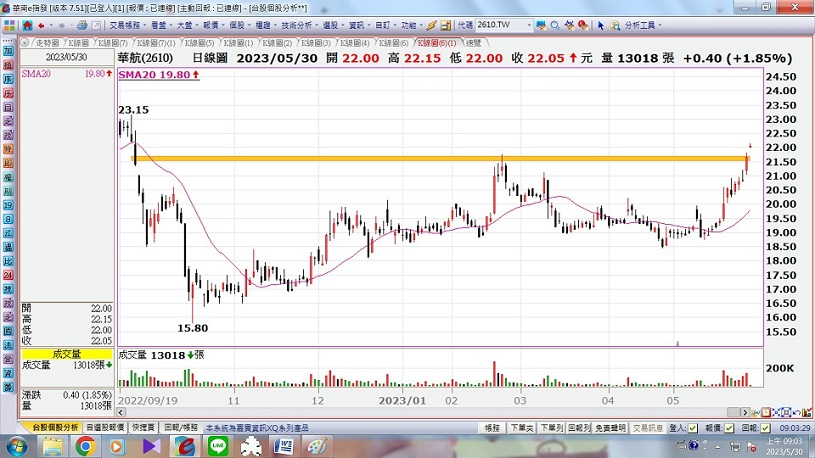

In [3]:
##### 使用2022年9月19日到本日(2023年6月13日)收盤之日線圖資料 #####
# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_2610_230613.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

頸線價格 ： 21.65元


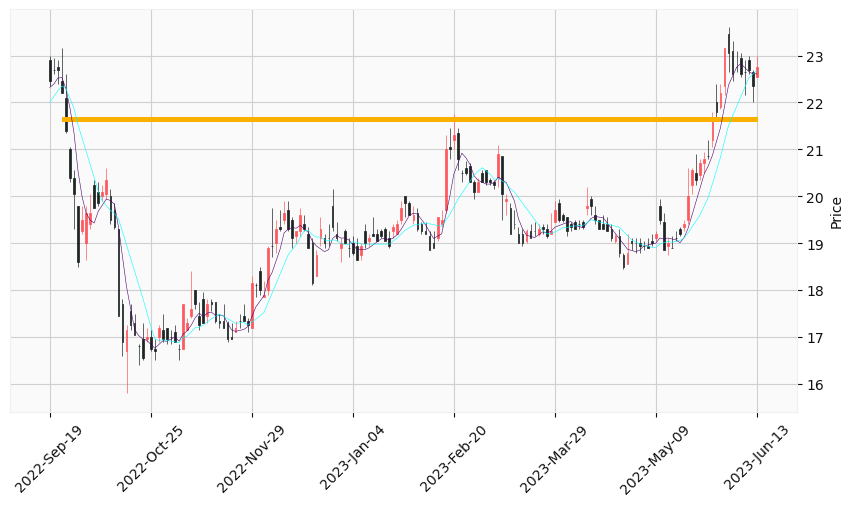

In [4]:
# 手動設定頸線
neckline_price = df_k_line.loc['2023-05-29']['Close']
neckline_start_date = '2022-09-22'
neckline_end_date = '2023-06-13'
print('頸線價格 ： {}元'.format(neckline_price))

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
                     ]

# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.4,color='xkcd:royal purple'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.4,color='xkcd:cyan')
            }

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()),alines=dict(alines=seq_of_seq_of_points, linewidths=2.5, colors=('xkcd:yellow orange')))
mpf.plot(df_k_line,**kwargs)

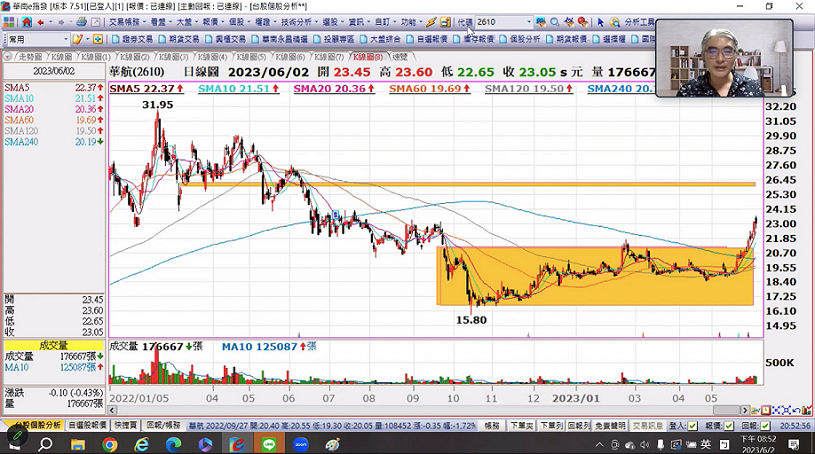
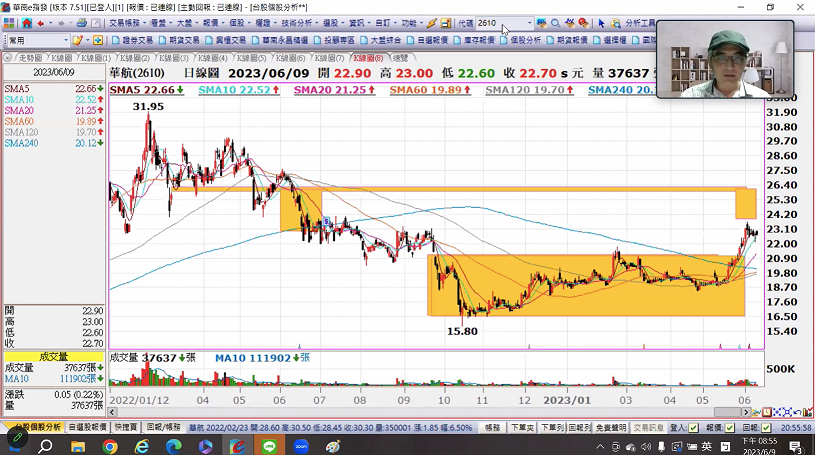

頸線價格 ： 21.2
目標價　 ： 25.85


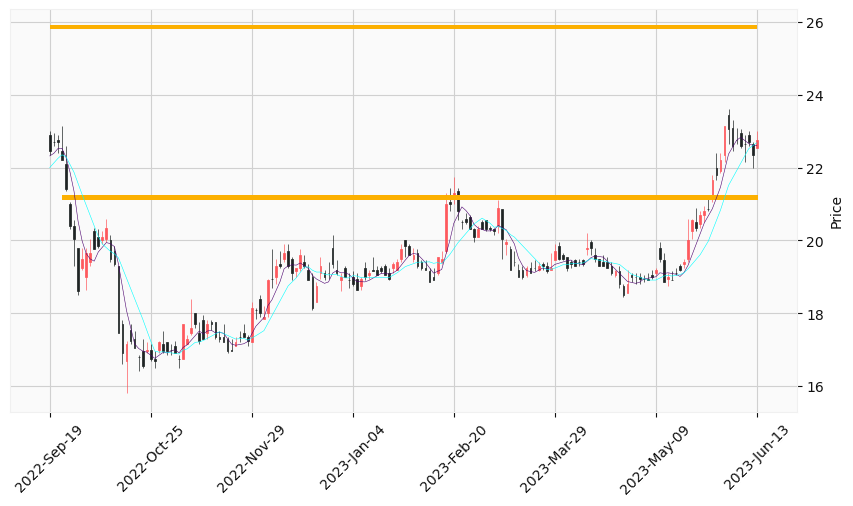

In [5]:
# 手動設定頸線
neckline_price = df_k_line.loc['2023-02-20']['Open']
neckline_start_date = '2022-09-22'
neckline_end_date = '2023-06-13'
print('頸線價格 ： {}'.format(neckline_price))

# 計算目標價
local_min_price = df_k_line.loc['2022-10-21']['Close']
target_price = round((neckline_price-local_min_price)+neckline_price,2)
target_start_date = '2022-09-19'
target_end_date = '2023-06-13'
print('目標價　 ： {}'.format(target_price))

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
    [(target_start_date,target_price),(target_end_date,target_price)]
                     ]

# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.4,color='xkcd:royal purple'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.4,color='xkcd:cyan')
            }

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()),alines=dict(alines=seq_of_seq_of_points, linewidths=(2.5,1.5), colors=('xkcd:yellow orange')))
mpf.plot(df_k_line,**kwargs)


* [TradingView](https://www.tradingview.com/) — Help Center and Support ： [Chart Patterns ](https://www.tradingview.com/support/folders/43000587407-chart-patterns/?folder=43000587407)  
* [stock-pattern-recorginition](https://github.com/CharlesLoo/stock-pattern-recorginition)  
* [stockPrediction_CNN](https://github.com/CharlesLoo/stockPrediction_CNN)  